# Fictalent · Auditoria de qualidade · segurança, quem pode ver o quê
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar usuários, perfis, a matriz de permissão e a trilha de auditoria do sistema do cliente. Não há telas neste projeto, então o módulo existe modelado e populado; o que se audita é se a trilha conta uma história possível (quem fez o quê, quando, com que perfil) e se a matriz de acesso é completa e coerente.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `seguranca`: `perfil`, `usuario`, `usuario_perfil`, `permissao`, `log_auditoria`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. Todo evento da trilha foi feito por um usuário que existia, estava ativo e tinha perfil vigente naquele instante?
2. O registro que a trilha diz ter sido alterado existe na tabela que ela nomeia, e o instante bate com o carimbo do registro?
3. A matriz de permissão cobre todos os perfis, módulos e ações, sem buraco, e a ação registrada era permitida ao perfil?
4. As exportações de dado pessoal (ação EXPORTAR) estão em volume plausível, e por quem?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude e coerência](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [A trilha contra as tabelas que ela nomeia](#secao-7)
8. [Cronologia e vigências](#secao-8)
9. [Integridade referencial](#secao-9)
10. [Regras do domínio](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("seguranca")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("seguranca")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

5 tabelas do domínio: perfil, usuario, usuario_perfil, permissao, log_auditoria


## Nota Técnica

**Observado:** mesma configuração; as 5 tabelas do módulo lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 146.911


,tabela,linhas_vivas,marca
0,seguranca.perfil,6,2026-09-24 15:02:06.227515
1,seguranca.usuario,40,2026-09-24 15:02:06.227515
2,seguranca.usuario_perfil,45,2026-09-24 15:02:06.227515
3,seguranca.permissao,300,2026-09-24 15:02:06.227515
4,seguranca.log_auditoria,146520,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 146.911 linhas vivas: 40 usuários com 45 concessões de perfil, 6 perfis, a matriz de 300 permissões e 146.520 eventos de trilha (111.406 além dos logins).

**Por que importa:** não há telas neste projeto: o módulo existe modelado e populado, e a trilha é a base da auditoria de acesso da v1.0.0.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

42 colunas em 5 tabelas
Colunas com um valor só: 4 (seguranca.perfil.criado_em, seguranca.perfil.atualizado_em, seguranca.permissao.criado_em, seguranca.permissao.atualizado_em)
Colunas totalmente vazias: 1 (seguranca.usuario.colaborador_id)


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,seguranca.perfil,id,BIGINT,0,0.00,6,1,6
1,seguranca.perfil,codigo,VARCHAR,0,0.00,6,ASSISTENTE,TI
2,seguranca.perfil,nome,VARCHAR,0,0.00,6,Assistente de setor,Tecnologia da informação
3,seguranca.perfil,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:29:00,2018-01-02 08:29:00
4,seguranca.perfil,atualizado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:29:00,2018-01-02 08:29:00
5,seguranca.usuario,id,BIGINT,0,0.00,41,1,40
6,seguranca.usuario,login,VARCHAR,0,0.00,40,aline.moreira,yasmin.frade
7,seguranca.usuario,nome,VARCHAR,0,0.00,43,Aline Ferraz Moreira,Yasmin Toledo Frade
8,seguranca.usuario,email,VARCHAR,0,0.00,39,aline.moreira@fictalent.example,yasmin.frade@fictalent.example
9,seguranca.usuario,colaborador_id,BIGINT,40,100.00,0,NaN,NaN


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

42 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


## Nota Técnica

**Observado:** 42 colunas, tipos compatíveis com a DDL; os carimbos de perfil e permissão são constantes (catálogo) e `usuario.colaborador_id` é totalmente nula.

**Por que importa:** a coluna vazia aponta para a seção 4: os usuários internos não estão ligados à tabela de colaboradores.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. Completude e coerência

Usuário ativo com acesso recente, inativo sem perfil vigente; usuário com colaborador; evento de edição com valor anterior e novo; evento sobre registro com o id do registro.

In [6]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 6; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
9,seguranca.usuario,colaborador_id,BIGINT,40,100.00,False
38,seguranca.log_auditoria,valor_anterior,VARCHAR,111791,76.30,False
21,seguranca.usuario_perfil,vigencia_fim,DATE,34,75.56,False
39,seguranca.log_auditoria,valor_novo,VARCHAR,87400,59.65,False
19,seguranca.usuario_perfil,filial_id,BIGINT,14,31.11,False
36,seguranca.log_auditoria,registro_id,BIGINT,24391,16.65,False


In [7]:
coerencia = consulta.sql(con, '''
    SELECT 'usuario ativo sem nenhum acesso' AS caso, count(*) AS linhas FROM seguranca.usuario WHERE excluido_em IS NULL AND ativo AND ultimo_acesso IS NULL
    UNION ALL SELECT 'usuario ativo sem acesso ha mais de 90 dias', count(*) FROM seguranca.usuario WHERE excluido_em IS NULL AND ativo AND ultimo_acesso < ?::TIMESTAMP - INTERVAL 90 DAY
    UNION ALL SELECT 'usuario inativo com perfil vigente', count(*) FROM seguranca.usuario u WHERE u.excluido_em IS NULL AND NOT u.ativo AND EXISTS (SELECT 1 FROM seguranca.usuario_perfil p WHERE p.excluido_em IS NULL AND p.usuario_id = u.id AND p.vigencia_fim IS NULL)
    UNION ALL SELECT 'usuario ativo sem perfil vigente', count(*) FROM seguranca.usuario u WHERE u.excluido_em IS NULL AND u.ativo AND NOT EXISTS (SELECT 1 FROM seguranca.usuario_perfil p WHERE p.excluido_em IS NULL AND p.usuario_id = u.id AND p.vigencia_inicio <= ? AND coalesce(p.vigencia_fim, DATE '9999-12-31') >= ?)
    UNION ALL SELECT 'usuario sem colaborador', count(*) FROM seguranca.usuario WHERE excluido_em IS NULL AND colaborador_id IS NULL
    UNION ALL SELECT 'usuario ativo cujo colaborador esta inativo', count(*) FROM seguranca.usuario u JOIN pessoas.colaborador c ON c.id = u.colaborador_id WHERE u.excluido_em IS NULL AND u.ativo AND NOT c.ativo
    UNION ALL SELECT 'ultimo_acesso anterior a criacao', count(*) FROM seguranca.usuario WHERE excluido_em IS NULL AND ultimo_acesso < dt_criacao
    UNION ALL SELECT 'email fora do formato', count(*) FROM seguranca.usuario WHERE excluido_em IS NULL AND NOT regexp_matches(email, '^[^@\\s]+@[^@\\s]+\\.[^@\\s]+$')
    UNION ALL SELECT 'log sem registro_id em acao que nao e LOGIN', count(*) FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND acao <> 'LOGIN' AND registro_id IS NULL
    UNION ALL SELECT 'log sem registro_id em acao que nao e LOGIN nem EXPORTAR', count(*) FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND acao NOT IN ('LOGIN', 'EXPORTAR') AND registro_id IS NULL
    UNION ALL SELECT 'log EDITAR sem valor_anterior ou sem valor_novo', count(*) FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND acao = 'EDITAR' AND (valor_anterior IS NULL OR valor_novo IS NULL)
    UNION ALL SELECT 'log CRIAR com valor_anterior', count(*) FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND acao = 'CRIAR' AND valor_anterior IS NOT NULL
    UNION ALL SELECT 'log EXCLUIR com valor_novo', count(*) FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND acao = 'EXCLUIR' AND valor_novo IS NOT NULL
''', HOJE, HOJE, HOJE)
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))
n_usuarios = checagens.linhas(con, "seguranca.usuario")
sem_colaborador = int(coerencia.loc[coerencia["caso"] == "usuario sem colaborador", "linhas"].iloc[0])
registro.anotar(
    secao="4", tabela="seguranca.usuario", coluna="colaborador_id",
    achado="usuário sem vínculo com a tabela de colaboradores (a retaguarda não está modelada como colaborador)", linhas=sem_colaborador, total=n_usuarios, severidade="baixa",
    impacto="a trilha diz o login mas não diz quem é a pessoa, em que setor e filial está e se ainda trabalha na empresa",
    acao="modelar a retaguarda como colaborador, ou aceitar e documentar",
)

Testes de coerência: 13; com linhas: 2
                                                    caso  linhas
                         usuario ativo sem nenhum acesso       0
             usuario ativo sem acesso ha mais de 90 dias       0
                      usuario inativo com perfil vigente       0
                        usuario ativo sem perfil vigente       0
                                 usuario sem colaborador      40
             usuario ativo cujo colaborador esta inativo       0
                        ultimo_acesso anterior a criacao       0
                                   email fora do formato       0
             log sem registro_id em acao que nao e LOGIN   24391
log sem registro_id em acao que nao e LOGIN nem EXPORTAR       0
         log EDITAR sem valor_anterior ou sem valor_novo       0
                            log CRIAR com valor_anterior       0
                              log EXCLUIR com valor_novo       0


Achado(dominio='seguranca', secao='4', tabela='seguranca.usuario', coluna='colaborador_id', achado='usuário sem vínculo com a tabela de colaboradores (a retaguarda não está modelada como colaborador)', linhas=40, total=40, severidade='baixa', impacto='a trilha diz o login mas não diz quem é a pessoa, em que setor e filial está e se ainda trabalha na empresa', acao='modelar a retaguarda como colaborador, ou aceitar e documentar', declaracao='')

## Nota Técnica

**Observado:** 6 colunas com nulo, nenhuma `NOT NULL`. Dos 13 testes de coerência, 11 passaram: todo usuário ativo acessou nos últimos 90 dias, nenhum inativo tem perfil vigente, todo ativo tem perfil, e-mail no formato, evento de edição sempre com valor anterior e novo. Os dois que não: os 40 usuários não têm vínculo com `pessoas.colaborador` (a coluna é nula em todos), e 24.391 eventos não têm `registro_id`, todos eles exportações, o que é regra (uma exportação não é sobre um registro só).

**Por que importa:** sem o vínculo ao colaborador, a trilha diz o login mas não diz quem é a pessoa, em que setor e filial ela está e se ela ainda trabalha na Fictalent; a retaguarda (assistentes, coordenadores, financeiro, sócios) não está na tabela de colaboradores, que só tem quem vai a campo.

**Ação:** anotar o usuário sem colaborador como achado de severidade baixa: modelar a retaguarda como colaborador, ou aceitar e documentar. A exportação sem registro fica registrada como regra, não como defeito.

<a id="secao-5"></a>

# 5. Unicidade

Login, código de perfil e permissão por perfil, módulo e ação são `UNIQUE`; e-mail e nome deveriam ser; o mesmo perfil concedido duas vezes ao mesmo usuário no mesmo período é sobreposição.

In [8]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
print(unicas.to_string(index=False))
for tabela, colunas, descricao in (("seguranca.usuario", ["email"], "o mesmo e-mail em dois usuarios"), ("seguranca.usuario", ["nome"], "o mesmo nome em dois usuarios (normalizado)")):
    grupos, envolvidas = checagens.repetidos(con, tabela, colunas, normalizar=True)
    print(f"{tabela:<20} {'+'.join(colunas):<8} {grupos:>4} grupos  {envolvidas:>5} linhas   ({descricao})")
print(f"usuario_perfil: o mesmo perfil concedido duas vezes ao mesmo usuário em períodos que se cruzam: {checagens.sobreposicoes(con, 'seguranca.usuario_perfil', ['usuario_id', 'perfil_id'], 'vigencia_inicio', 'vigencia_fim')}")

3 chaves UNIQUE conferidas; com repetição: 0
             tabela                   chave  grupos_repetidos  linhas
   seguranca.perfil                  codigo                 0       0
  seguranca.usuario                   login                 0       0
seguranca.permissao perfil_id, modulo, acao                 0       0
seguranca.usuario    email       0 grupos      0 linhas   (o mesmo e-mail em dois usuarios)
seguranca.usuario    nome        0 grupos      0 linhas   (o mesmo nome em dois usuarios (normalizado))
usuario_perfil: o mesmo perfil concedido duas vezes ao mesmo usuário em períodos que se cruzam: 0


## Nota Técnica

**Observado:** as 3 chaves `UNIQUE` íntegras, nenhum e-mail ou nome repetido, nenhum perfil concedido duas vezes ao mesmo usuário em períodos que se cruzam.

**Por que importa:** cada login é uma pessoa e cada pessoa tem um caminho de perfil sem sobreposição.

**Ação:** nenhuma.

<a id="secao-6"></a>

# 6. Domínios declarados

Os domínios em `CHECK`, a distribuição, e a matriz de permissão: todo perfil tem uma decisão para todo módulo e toda ação?

In [9]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
display(dominios)
for tabela, coluna in (("seguranca.perfil", "codigo"), ("seguranca.permissao", "modulo"), ("seguranca.log_auditoria", "acao"), ("seguranca.log_auditoria", "modulo")):
    print(f"{tabela}.{coluna}: " + ", ".join(f"{v}={n}" for v, n in con.execute(f"SELECT {coluna}, count(*) FROM {tabela} WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").fetchall()))
matriz = consulta.sql(con, '''
    SELECT (SELECT count(*) FROM seguranca.perfil WHERE excluido_em IS NULL) AS perfis, count(DISTINCT modulo) AS modulos, count(DISTINCT acao) AS acoes,
           count(*) AS permissoes, (SELECT count(*) FROM seguranca.perfil WHERE excluido_em IS NULL) * count(DISTINCT modulo) * count(DISTINCT acao) AS esperadas,
           count(*) FILTER (WHERE fl_permitido) AS permitidas
    FROM seguranca.permissao WHERE excluido_em IS NULL''')
print(matriz.to_string(index=False))
print(consulta.sql(con, "SELECT p.codigo AS perfil, count(*) FILTER (WHERE m.fl_permitido) AS permitidas, count(*) FILTER (WHERE m.fl_permitido AND m.acao = 'EXPORTAR') AS pode_exportar, count(*) FILTER (WHERE m.fl_permitido AND m.acao = 'EXCLUIR') AS pode_excluir FROM seguranca.perfil p JOIN seguranca.permissao m ON m.perfil_id = p.id AND m.excluido_em IS NULL WHERE p.excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").to_string(index=False))

3 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,seguranca.perfil,codigo,6,0,
1,seguranca.permissao,acao,5,0,
2,seguranca.log_auditoria,acao,5,0,


seguranca.perfil.codigo: FINANCEIRO=1, SOCIO=1, GERENTE=1, TI=1, ASSISTENTE=1, COORDENADOR=1
seguranca.permissao.modulo: ats=30, treinamento=30, ponto=30, sst=30, comercial=30, folha=30, cadastro=30, seguranca=30, pessoas=30, financeiro=30
seguranca.log_auditoria.acao: CRIAR=52286, LOGIN=35114, EDITAR=34729, EXPORTAR=24391
seguranca.log_auditoria.modulo: pessoas=51285, ats=46842, seguranca=35151, financeiro=3491, comercial=3054, ponto=2332, folha=2277, treinamento=1060, sst=1028
 perfis  modulos  acoes  permissoes  esperadas  permitidas
      6       10      5         300        300         123


     perfil  permitidas  pode_exportar  pode_excluir
COORDENADOR          30              7             1
    GERENTE          22              9             0
 ASSISTENTE          22              5             0
      SOCIO          19              9             0
         TI          18              2             2
 FINANCEIRO          12              2             0


## Nota Técnica

**Observado:** os 3 domínios só têm valores previstos e a matriz de permissão está completa: 6 perfis × 10 módulos × 5 ações = 300 decisões, 123 delas permitidas. Coordenador é o perfil mais amplo (30 permissões), só TI e coordenador podem excluir, e nove perfis-módulo permitem exportar ao sócio e ao gerente.

**Por que importa:** matriz completa é o que permite conferir cada evento da trilha contra o que era permitido (seção 7).

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. A trilha contra as tabelas que ela nomeia

Cada evento diz módulo, tabela e id do registro. O registro existe? O instante do evento CRIAR bate com o carimbo `criado_em` do registro? A ação era permitida ao perfil do usuário naquele dia?

In [10]:
print(consulta.sql(con, "SELECT modulo, tabela, count(*) AS eventos, count(registro_id) AS com_registro FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND acao <> 'LOGIN' GROUP BY 1, 2 ORDER BY 3 DESC").to_string(index=False))

     modulo            tabela  eventos  com_registro
        ats              vaga    40746         37679
    pessoas contrato_trabalho    32843         32843
    pessoas      desligamento    16134         16134
        ats       candidatura     3085             0
        ats        entrevista     3011             0
      ponto       apontamento     2332             0
    pessoas          alocacao     2308             0
      folha        folha_item     2277             0
 financeiro    titulo_receber     1814             0
 financeiro            fatura     1677             0
  comercial          contrato     1553           204
  comercial             posto     1346             0
treinamento       certificado     1060             0
        sst               aso     1028             0
  comercial           cliente      155           155
  seguranca           usuario       37             0


In [11]:
alvos = consulta.sql(con, "SELECT modulo, tabela, count(*) AS eventos FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND acao <> 'LOGIN' AND registro_id IS NOT NULL GROUP BY 1, 2 ORDER BY 3 DESC")
linhas = []
for modulo, tabela, eventos in alvos.itertuples(index=False):
    alvo = f"{modulo}.{tabela}"
    r = consulta.sql(con, f'''
        SELECT count(*) AS eventos,
               count(*) FILTER (WHERE t.id IS NULL) AS registro_inexistente,
               count(*) FILTER (WHERE l.acao = 'CRIAR' AND t.id IS NOT NULL AND abs(date_diff('minute', l.dt_evento, t.criado_em)) > 1) AS criar_fora_do_carimbo,
               count(*) FILTER (WHERE l.acao = 'EDITAR' AND t.id IS NOT NULL AND l.dt_evento > t.atualizado_em + INTERVAL 1 MINUTE) AS editar_depois_da_ultima_atualizacao,
               count(*) FILTER (WHERE t.id IS NOT NULL AND l.dt_evento < t.criado_em - INTERVAL 1 MINUTE) AS evento_antes_de_o_registro_existir
        FROM seguranca.log_auditoria l LEFT JOIN {alvo} t ON t.id = l.registro_id
        WHERE l.excluido_em IS NULL AND l.modulo = ? AND l.tabela = ? AND l.registro_id IS NOT NULL''', modulo, tabela)
    linhas.append({"alvo": alvo, **r.iloc[0].to_dict()})
trilha = pd.DataFrame(linhas)
print(trilha.to_string(index=False))
conferidos = int(trilha["eventos"].sum())
defeitos_trilha = int(trilha[["registro_inexistente", "criar_fora_do_carimbo", "editar_depois_da_ultima_atualizacao", "evento_antes_de_o_registro_existir"]].to_numpy().sum())
registro.anotar(
    secao="7", tabela="seguranca.log_auditoria", coluna="modulo, tabela, registro_id, dt_evento",
    achado="hipótese refutada: todo registro nomeado pela trilha existe, todo CRIAR bate com o carimbo de criação e nenhum EDITAR é posterior à última atualização", linhas=defeitos_trilha, total=conferidos, severidade="nenhuma",
    impacto="a trilha é fiel às tabelas que descreve e pode ser usada como prova", acao="nenhuma",
)

                     alvo  eventos  registro_inexistente  criar_fora_do_carimbo  editar_depois_da_ultima_atualizacao  evento_antes_de_o_registro_existir
                 ats.vaga    37679                     0                      0                                    0                                   0
pessoas.contrato_trabalho    32843                     0                      0                                    0                                   0
     pessoas.desligamento    16134                     0                      0                                    0                                   0
       comercial.contrato      204                     0                      0                                    0                                   0
        comercial.cliente      155                     0                      0                                    0                                   0


Achado(dominio='seguranca', secao='7', tabela='seguranca.log_auditoria', coluna='modulo, tabela, registro_id, dt_evento', achado='hipótese refutada: todo registro nomeado pela trilha existe, todo CRIAR bate com o carimbo de criação e nenhum EDITAR é posterior à última atualização', linhas=0, total=87015, severidade='nenhuma', impacto='a trilha é fiel às tabelas que descreve e pode ser usada como prova', acao='nenhuma', declaracao='')

In [12]:
permitido = consulta.sql(con, '''
    SELECT count(*) AS eventos,
           count(*) FILTER (WHERE NOT EXISTS (
             SELECT 1 FROM seguranca.usuario_perfil up JOIN seguranca.permissao m ON m.perfil_id = up.perfil_id AND m.excluido_em IS NULL
             WHERE up.excluido_em IS NULL AND up.usuario_id = l.usuario_id AND CAST(l.dt_evento AS DATE) BETWEEN up.vigencia_inicio AND coalesce(up.vigencia_fim, DATE '9999-12-31')
               AND m.modulo = l.modulo AND m.acao = l.acao AND m.fl_permitido)) AS sem_permissao_vigente
    FROM seguranca.log_auditoria l WHERE l.excluido_em IS NULL AND l.acao <> 'LOGIN' ''')
print(permitido.to_string(index=False))
print(consulta.sql(con, '''
    SELECT l.acao, count(*) AS eventos_sem_permissao FROM seguranca.log_auditoria l WHERE l.excluido_em IS NULL AND l.acao <> 'LOGIN' AND NOT EXISTS (
      SELECT 1 FROM seguranca.usuario_perfil up JOIN seguranca.permissao m ON m.perfil_id = up.perfil_id AND m.excluido_em IS NULL
      WHERE up.excluido_em IS NULL AND up.usuario_id = l.usuario_id AND CAST(l.dt_evento AS DATE) BETWEEN up.vigencia_inicio AND coalesce(up.vigencia_fim, DATE '9999-12-31')
        AND m.modulo = l.modulo AND m.acao = l.acao AND m.fl_permitido) GROUP BY 1 ORDER BY 2 DESC''').to_string(index=False))
registro.anotar(
    secao="7", tabela="seguranca.log_auditoria", coluna="usuario_id, modulo, acao, dt_evento",
    achado="ação registrada na trilha sem permissão vigente do perfil do usuário naquele dia (a maioria exportações)", linhas=int(permitido.iloc[0]["sem_permissao_vigente"]), total=int(permitido.iloc[0]["eventos"]), severidade="media",
    impacto="ou o controle de acesso do sistema falha, ou o perfil foi concedido depois do fato; a exportação é o caso sensível pela LGPD",
    acao="a silver marca o evento; a auditoria de acesso lista por usuário; o cliente explica",
)
print(f"anotados: {len(registro)}")

 eventos  sem_permissao_vigente
  111406                   4092


    acao  eventos_sem_permissao
EXPORTAR                   3741
   CRIAR                    221
  EDITAR                    130
anotados: 3


## Nota Técnica

**Observado:** a trilha nomeia 16 tabelas de 9 módulos. Nas 5 em que os eventos têm `registro_id` (vaga, contrato de trabalho, desligamento, contrato comercial e cliente, 87.015 eventos), o registro existe em 100%, todo `CRIAR` bate com o carimbo de criação do registro no minuto, nenhum `EDITAR` é posterior à última atualização e nenhum evento antecede a existência do registro. **O que não passou: 4.092 dos 111.406 eventos (3,7%) foram feitos por usuários que, naquele dia, não tinham perfil com aquela ação permitida naquele módulo**: 3.741 exportações, 221 criações e 130 edições.

**Por que importa:** a trilha é fiel às tabelas que descreve, o que é raro e vale dizer. Ação sem permissão vigente é ou uma falha do controle de acesso do sistema, ou perfil concedido depois do fato e retroagido; em ambos os casos é achado de auditoria de acesso, e a exportação é o caso sensível pela LGPD.

**Ação:** anotar como achado de severidade média: a silver marca o evento; a auditoria de acesso da v1.0.0 lista por usuário; o cliente explica.

<a id="secao-8"></a>

# 8. Cronologia e vigências

Evento depois da criação do usuário, dentro da vigência de algum perfil, nunca no futuro; perfil concedido depois da criação do usuário; último acesso coerente com a trilha.

In [13]:
tempo = consulta.sql(con, '''
    SELECT 'evento no futuro' AS caso, count(*) AS linhas FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND CAST(dt_evento AS DATE) > ?
    UNION ALL SELECT 'evento antes da criacao do usuario', count(*) FROM seguranca.log_auditoria l JOIN seguranca.usuario u ON u.id = l.usuario_id WHERE l.excluido_em IS NULL AND CAST(l.dt_evento AS DATE) < u.dt_criacao
    UNION ALL SELECT 'evento sem perfil vigente no dia', count(*) FROM seguranca.log_auditoria l WHERE l.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM seguranca.usuario_perfil p WHERE p.excluido_em IS NULL AND p.usuario_id = l.usuario_id AND CAST(l.dt_evento AS DATE) BETWEEN p.vigencia_inicio AND coalesce(p.vigencia_fim, DATE '9999-12-31'))
    UNION ALL SELECT 'evento depois do ultimo_acesso do usuario', count(*) FROM seguranca.log_auditoria l JOIN seguranca.usuario u ON u.id = l.usuario_id WHERE l.excluido_em IS NULL AND u.ultimo_acesso IS NOT NULL AND l.dt_evento > u.ultimo_acesso + INTERVAL 1 DAY
    UNION ALL SELECT 'perfil concedido antes da criacao do usuario', count(*) FROM seguranca.usuario_perfil p JOIN seguranca.usuario u ON u.id = p.usuario_id WHERE p.excluido_em IS NULL AND p.vigencia_inicio < u.dt_criacao
    UNION ALL SELECT 'perfil com vigencia_fim antes do inicio', count(*) FROM seguranca.usuario_perfil WHERE excluido_em IS NULL AND vigencia_fim < vigencia_inicio
    UNION ALL SELECT 'evento fora do horario comercial (antes das 6h ou depois das 22h)', count(*) FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND (hour(dt_evento) < 6 OR hour(dt_evento) >= 22)
    UNION ALL SELECT 'evento em domingo (operacao 6x1, informativo)', count(*) FROM seguranca.log_auditoria WHERE excluido_em IS NULL AND dayofweek(dt_evento) = 0
''', HOJE)
print(tempo.to_string(index=False))
n_eventos = checagens.linhas(con, "seguranca.log_auditoria")
registro.anotar(
    secao="8", tabela="seguranca.log_auditoria", coluna="dt_evento, usuario.ultimo_acesso",
    achado="evento posterior ao último acesso registrado do usuário", linhas=int(tempo.loc[tempo["caso"] == "evento depois do ultimo_acesso do usuario", "linhas"].iloc[0]), total=n_eventos, severidade="baixa",
    impacto="o último acesso não é confiável como indicador de atividade", acao="marcar; usar a trilha, não o campo, para saber quando o usuário acessou",
)

                                                             caso  linhas
                                                 evento no futuro       0
                               evento antes da criacao do usuario       0
                                 evento sem perfil vigente no dia       0
                        evento depois do ultimo_acesso do usuario       9
                     perfil concedido antes da criacao do usuario       0
                          perfil com vigencia_fim antes do inicio       0
evento fora do horario comercial (antes das 6h ou depois das 22h)       0
                    evento em domingo (operacao 6x1, informativo)    7287


Achado(dominio='seguranca', secao='8', tabela='seguranca.log_auditoria', coluna='dt_evento, usuario.ultimo_acesso', achado='evento posterior ao último acesso registrado do usuário', linhas=9, total=146520, severidade='baixa', impacto='o último acesso não é confiável como indicador de atividade', acao='marcar; usar a trilha, não o campo, para saber quando o usuário acessou', declaracao='')

## Nota Técnica

**Observado:** nenhum evento no futuro, antes da criação do usuário ou sem perfil vigente no dia; nenhum evento fora do horário comercial. Nove eventos são posteriores ao último acesso registrado do usuário (o último acesso não foi atualizado), e 7.287 eventos caem em domingo, o que é compatível com a operação 6x1 e o fechamento de ponto no fim de semana.

**Por que importa:** o último acesso desatualizado é um detalhe do sistema; o domingo é regra da operação.

**Ação:** anotar os nove eventos como baixa.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira do módulo.

In [14]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
integridade

7 chaves estrangeiras conferidas; com órfãos: 0


,tabela,coluna,alvo,orfaos
0,seguranca.usuario,colaborador_id,pessoas.colaborador,0
1,seguranca.usuario,filial_id,cadastro.filial,0
2,seguranca.usuario_perfil,usuario_id,seguranca.usuario,0
3,seguranca.usuario_perfil,perfil_id,seguranca.perfil,0
4,seguranca.usuario_perfil,filial_id,cadastro.filial,0
5,seguranca.permissao,perfil_id,seguranca.perfil,0
6,seguranca.log_auditoria,usuario_id,seguranca.usuario,0


## Nota Técnica

**Observado:** as 7 chaves estrangeiras sem órfão.

**Por que importa:** junções seguras.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. Regras do domínio

As exportações de dado pessoal por ano e por perfil, os usuários que mais exportam, e a proporção de eventos por ação: é o retrato de como o sistema é usado, e a base da auditoria de acesso da v1.0.0.

In [15]:
por_ano = consulta.sql(con, '''
    SELECT year(l.dt_evento) AS ano, count(*) AS eventos, count(DISTINCT l.usuario_id) AS usuarios_ativos,
           count(*) FILTER (WHERE l.acao = 'EXPORTAR') AS exportacoes, round(100.0 * count(*) FILTER (WHERE l.acao = 'EXPORTAR') / count(*), 2) AS pct_exportar,
           count(*) FILTER (WHERE l.acao = 'EXCLUIR') AS exclusoes, count(*) FILTER (WHERE l.acao = 'LOGIN') AS logins
    FROM seguranca.log_auditoria l WHERE l.excluido_em IS NULL GROUP BY 1 ORDER BY 1''')
print(por_ano.to_string(index=False))
print()
print(consulta.sql(con, '''
    SELECT p.codigo AS perfil, count(*) AS exportacoes, count(DISTINCT l.usuario_id) AS usuarios
    FROM seguranca.log_auditoria l JOIN seguranca.usuario_perfil up ON up.usuario_id = l.usuario_id AND up.excluido_em IS NULL AND CAST(l.dt_evento AS DATE) BETWEEN up.vigencia_inicio AND coalesce(up.vigencia_fim, DATE '9999-12-31')
    JOIN seguranca.perfil p ON p.id = up.perfil_id
    WHERE l.excluido_em IS NULL AND l.acao = 'EXPORTAR' GROUP BY 1 ORDER BY 2 DESC''').to_string(index=False))
print()
print(consulta.sql(con, '''
    SELECT u.login, p.codigo AS perfil_atual, count(*) AS eventos, count(*) FILTER (WHERE l.acao = 'EXPORTAR') AS exportacoes, max(l.dt_evento)::DATE AS ultimo_evento
    FROM seguranca.log_auditoria l JOIN seguranca.usuario u ON u.id = l.usuario_id
    LEFT JOIN seguranca.usuario_perfil up ON up.usuario_id = u.id AND up.vigencia_fim IS NULL AND up.excluido_em IS NULL LEFT JOIN seguranca.perfil p ON p.id = up.perfil_id
    WHERE l.excluido_em IS NULL GROUP BY 1, 2 ORDER BY 4 DESC, 3 DESC LIMIT 10''').to_string(index=False))
registro.anotar(
    secao="10", tabela="seguranca.log_auditoria", coluna="acao = EXPORTAR",
    achado=f"exportações de dado pessoal crescendo em número e em peso (de {por_ano['pct_exportar'].iloc[0]}% para {por_ano['pct_exportar'].iloc[-1]}% dos eventos), concentradas no perfil de assistente", linhas=int(por_ano["exportacoes"].sum()), total=n_eventos, severidade="nenhuma",
    impacto="não é defeito de dado: é o retrato de uma operação que vive de planilha, e a saída de dado pessoal que a LGPD manda monitorar",
    acao="indicador de exportações por usuário e perfil no painel de auditoria de acesso da v1.0.0",
)
print(f"anotados: {len(registro)}")

 ano  eventos  usuarios_ativos  exportacoes  pct_exportar  exclusoes  logins
2018     3168                7          372         11.74          0    1247
2019     6323               11          645         10.20          0    2019
2020     5591               12          731         13.07          0    2189
2021     8064               14          831         10.31          0    2716
2022    14229               20         1244          8.74          0    3776
2023    22012               26         2615         11.88          0    5096
2024    32075               29         5121         15.97          0    6297
2025    32588               32         7296         22.39          0    6731
2026    22470               34         5536         24.64          0    5043

     perfil  exportacoes  usuarios
 ASSISTENTE        16461        31
 FINANCEIRO         3065         4
COORDENADOR         2696         5
    GERENTE         2098         1
         TI           37         2
      SOCIO        

          login perfil_atual  eventos  exportacoes ultimo_evento
  sabrina.teles      GERENTE     4252         2177    2026-09-10
claudio.antunes   FINANCEIRO     3316         1280    2026-09-09
   rafaela.dias   ASSISTENTE     5392         1135    2026-09-10
 priscila.couto   ASSISTENTE    15135         1107    2026-09-10
   jessica.leal   ASSISTENTE    22716          976    2026-09-10
 patricia.matos   FINANCEIRO     2016          928    2026-09-09
  marlene.pires  COORDENADOR     7080          922    2026-09-09
 fernanda.bento   ASSISTENTE     5617          888    2026-09-10
debora.carvalho  COORDENADOR     3519          888    2026-09-09
   gustavo.lins   ASSISTENTE     2085          870    2026-09-10
anotados: 5


## Nota Técnica

**Observado:** as exportações crescem em número e em peso: de 372 em 2018 para 7.296 em 2025, e de 10% a 12% dos eventos nos primeiros anos para 24,6% em 2026. As assistentes respondem por 16.461 exportações (31 usuárias); a gerente é a usuária que mais exporta (2.177). Nenhuma exclusão na trilha inteira.

**Por que importa:** exportação é a saída de dado pessoal do sistema, e um quarto dos eventos sendo exportação é o retrato de uma operação que vive de planilha, o que conversa com o consolidado da gerência auditado no financeiro. Não é defeito de dado; é o que a auditoria de acesso vai monitorar.

**Ação:** nenhuma na silver; anotar como `nenhuma` com a ação: indicador de exportações por usuário no painel de auditoria da v1.0.0.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [16]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        0
     media        1
     baixa        2
   nenhuma        2

Total: 5 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,media,7,seguranca.log_auditoria,"usuario_id, modulo, acao, dt_evento",ação registrada na trilha sem permissão vigente do perfil do usuário naquele dia (a maioria expo...,4092,111406,3.67,
1,baixa,4,seguranca.usuario,colaborador_id,usuário sem vínculo com a tabela de colaboradores (a retaguarda não está modelada como colaborador),40,40,100.00,
2,baixa,8,seguranca.log_auditoria,"dt_evento, usuario.ultimo_acesso",evento posterior ao último acesso registrado do usuário,9,146520,0.01,
3,nenhuma,10,seguranca.log_auditoria,acao = EXPORTAR,"exportações de dado pessoal crescendo em número e em peso (de 11.74% para 24.64% dos eventos), c...",24391,146520,16.65,
4,nenhuma,7,seguranca.log_auditoria,"modulo, tabela, registro_id, dt_evento","hipótese refutada: todo registro nomeado pela trilha existe, todo CRIAR bate com o carimbo de cr...",0,87015,0.00,


In [17]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,media,seguranca.log_auditoria,"usuario_id, modulo, acao, dt_evento","ou o controle de acesso do sistema falha, ou o perfil foi concedido depois do fato; a exportação...",a silver marca o evento; a auditoria de acesso lista por usuário; o cliente explica
1,baixa,seguranca.usuario,colaborador_id,"a trilha diz o login mas não diz quem é a pessoa, em que setor e filial está e se ainda trabalha...","modelar a retaguarda como colaborador, ou aceitar e documentar"
2,baixa,seguranca.log_auditoria,"dt_evento, usuario.ultimo_acesso",o último acesso não é confiável como indicador de atividade,"marcar; usar a trilha, não o campo, para saber quando o usuário acessou"
3,nenhuma,seguranca.log_auditoria,acao = EXPORTAR,"não é defeito de dado: é o retrato de uma operação que vive de planilha, e a saída de dado pesso...",indicador de exportações por usuário e perfil no painel de auditoria de acesso da v1.0.0
4,nenhuma,seguranca.log_auditoria,"modulo, tabela, registro_id, dt_evento",a trilha é fiel às tabelas que descreve e pode ser usada como prova,nenhuma


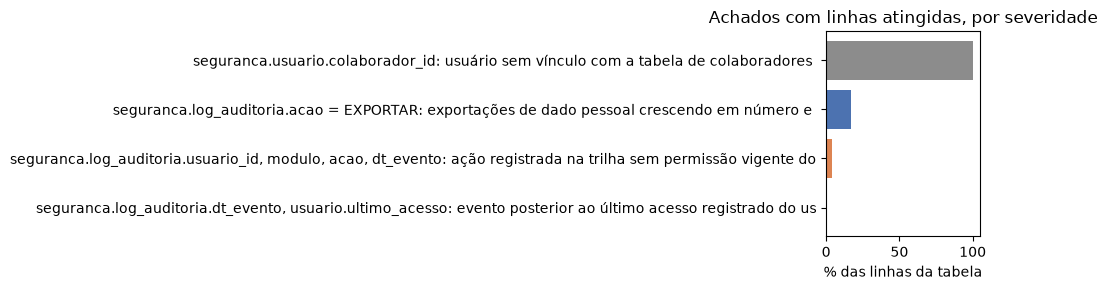

registro gravado em dados/auditoria/seguranca.json


In [18]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C", "nenhuma": "#4C72B0"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 5 tabelas do módulo `seguranca`, 42 colunas e 146.911 linhas vivas, na carga identificada na seção 2: tipo, completude, unicidade, a matriz de permissão, a trilha contra as tabelas que ela nomeia, cronologia, integridade referencial e o retrato do uso.

**O veredicto: a trilha é fiel e o controle de acesso tem uma fresta.** Em cinco tabelas e 87 mil eventos conferidos, o registro nomeado existe e o instante bate com o carimbo em 100%; a matriz está completa; os perfis não se sobrepõem. O achado é de acesso: 4.092 ações (3,7%), a maioria exportações, feitas sem permissão vigente do perfil (média). Os demais são pequenos: os 40 usuários sem vínculo com colaborador e nove eventos depois do último acesso (baixas). Dois registros de severidade nenhuma: a trilha íntegra e o crescimento das exportações, que vira indicador da auditoria de acesso.

**Próximos passos:** o fechamento, que consolida os nove domínios e confronta as seis declarações do cliente.